In [ ]:
from io import BytesIO
from os import environ

import dotenv
import marimo as mo
import numpy as np
import polars as pl
from cairosvg import svg2png
from perlin_numpy import generate_perlin_noise_2d
from PIL import Image, ImageChops, ImageDraw
import random

from meta import ROOT_DIR

In [ ]:
dotenv.load_dotenv(ROOT_DIR / ".env")


def collect_hg_dataset():
    df = pl.scan_parquet(
        "hf://datasets/OmniSVG/MMSVG-Icon/data/train-*-of-*.parquet",
        storage_options={"token": environ["HF_TOKEN"]},
    )
    path = ROOT_DIR / "data" / "svg_dataset.csv"
    print("started download")
    df.select("svg", "keywords").head(5000).collect().write_csv(path)
    print(f"dataset saved at {path}")


if not (ROOT_DIR / "data" / "svg_dataset.csv").exists():
    collect_hg_dataset()

mo.ui.run_button(
    label="Download svg dataset", on_change=lambda x: collect_hg_dataset()
)

In [ ]:
df = pl.read_csv(ROOT_DIR / "data" / "svg_dataset.csv")

In [ ]:
# number of images
N = 3000
# dimension of generated image
D = 256

In [ ]:
paths = (
    df.sample(N)
    .select(path=pl.col("svg").str.extract_all(r"<path .*></path>\s?"))
    .with_row_index("svg_idx")
    .explode("path")
)
synthetic_svg = (
    paths.with_columns(width=0.3*np.exp(3*np.random.random(size=len(paths))))
    .group_by("svg_idx")
    .agg(
        pl.col("path").str.replace(
            r'fill="#?\w*" *fill-opacity="1.0" *filling="0',
            pl.format(
                'stroke="black" stroke-width="{}" fill="none',
                pl.col("width"),
            ),
        )
    )
    .select(
        svg=pl.format(
            '<svg xmlns="http://www.w3.org/2000/svg" viewBox="0.0 0.0 200.0 200.0" height="{}.0px" width="{}.0px">{}</svg>',
            D, D, pl.col("path").list.join(""),
        )
    )["svg"]
)

In [ ]:
out_path = ROOT_DIR / "data" / "train"
out_path.mkdir(exist_ok=True)

def svg2image(source):
    png_data = BytesIO(svg2png(source))
    return Image.open(png_data)

images = [svg2image(x) for x in mo.status.progress_bar(synthetic_svg, title="Drawing SVG pictures")]


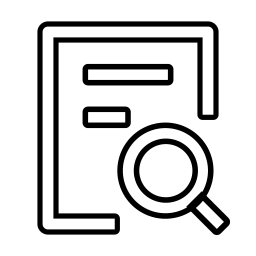
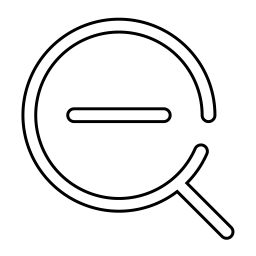
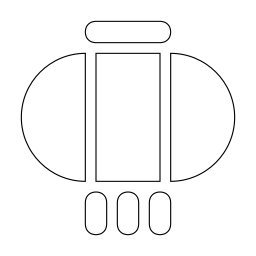
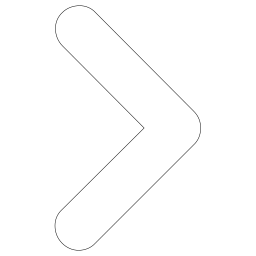
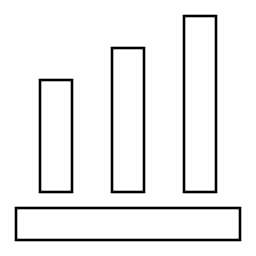
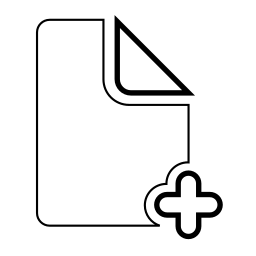
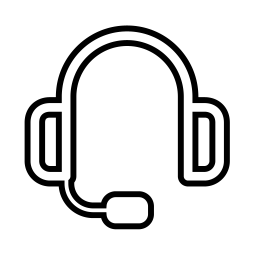
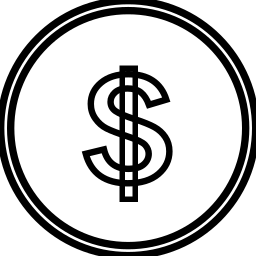
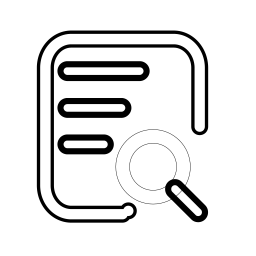
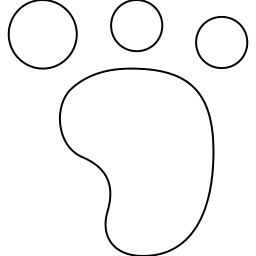

In [ ]:
mo.hstack(images[:10])

In [ ]:
def to_binary(image):
    rgba = Image.new("RGBA", (D, D), (0, 0, 0, 0))
    rgba.putalpha(
        Image.fromarray(np.asarray(image).sum(-1) > 1)
    )
    return rgba

def post_process(image):
    noise = 1.0*generate_perlin_noise_2d((D, D), (2, 2))
    noise += 1.0*generate_perlin_noise_2d((D, D), (8, 8))
    noise += 1.0*generate_perlin_noise_2d((D, D), (32, 32))
    noise = np.exp(noise)
    noise = noise / np.max(noise)
    noise_img = Image.fromarray((noise * 255).astype(np.uint8), mode="L")

    # Extract alpha and multiply with noise
    r, g, b, a = image.split()
    result = ImageChops.multiply(a, noise_img)

    # Add random line
    draw = ImageDraw.Draw(result)

    # Convert to RGBA: white RGB, result as alpha
    rgba = Image.new("RGBA", (D, D), (0, 0, 0, 0))
    rgba.putalpha(result)

    return rgba


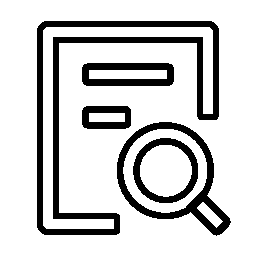
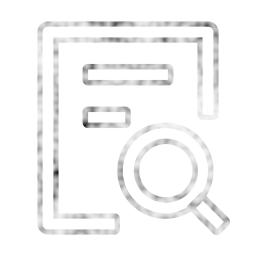
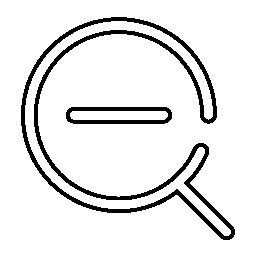
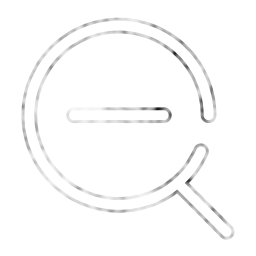
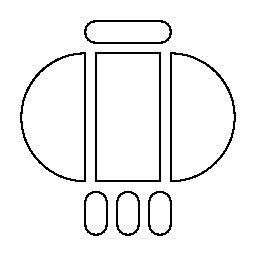
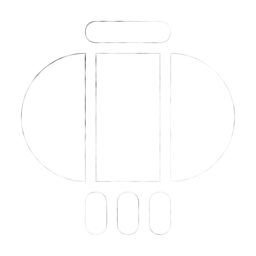
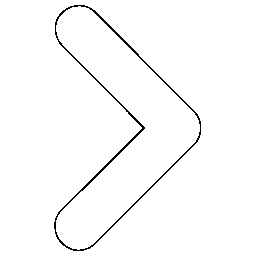
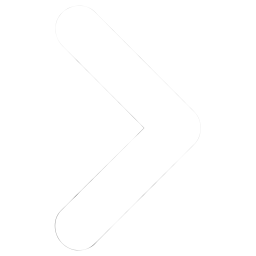
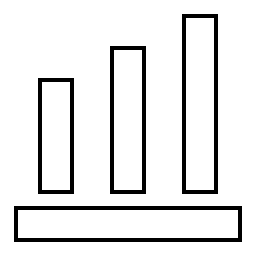
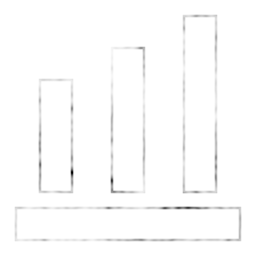
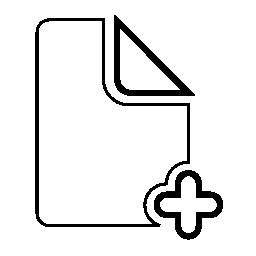
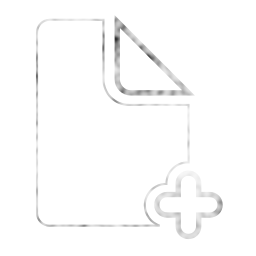
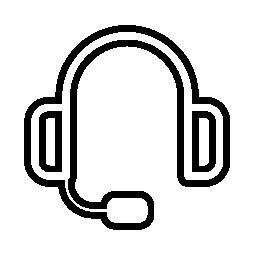
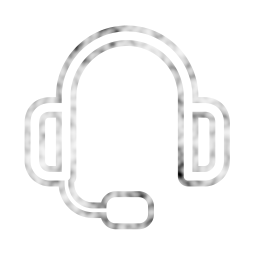
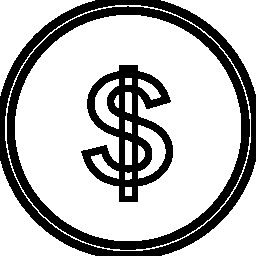
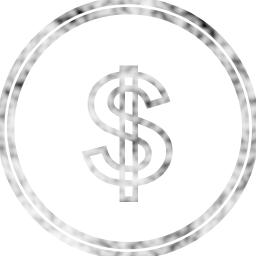
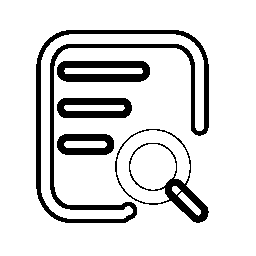
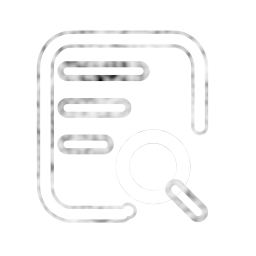
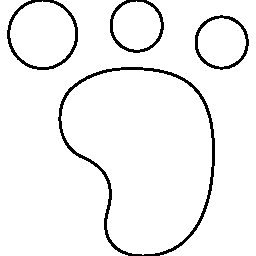
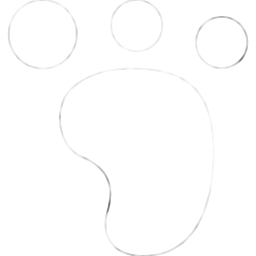

In [ ]:
mo.hstack([mo.vstack([to_binary(images[i]), post_process(images[i])]) for i in range(10)])

In [ ]:
for i, im in enumerate(
    mo.status.progress_bar(images, title="Adding noise and exporting ...")
):
    to_binary(im).save(out_path / f"y_{i}.png")
    post_process(im).save(out_path / f"x_{i}.png")